### Chapter-5

**5.1** We now review $k$-fold cross-validation.
_(a) Explain how $k$-fold cross-validation is implemented._
* **Answer:** Divide the dataset into k equal-sized subsets. Hold out one subset as validation set and use the remaining k-1 folds as training set. Train model on the training folds and evaluate the model on the held-out fold to obtain a validation score. Repeat this process for k times, each time using a different fold as validation and remaining as training set. After all k iterations are completed, average the k validation scores to produce final cross-validation estimate of the model's performance.

_(b) What are the advantages and disadvantages of $k$-fold crossvalidation relative to:_
  _* i. The validation set approach?_
  _* ii. LOOCV?_

* **Answer:** The advantage compared to validation set approach is that the k-fold cross-validation uses the entire data set for both training and validation instead of one single split, and average the estimated scores over k splits rather one score, so the result has less bias and more reliable. The disadvantage is higher computational cost. Also, validation set approach has lower variance and develops a model that generalizes to unseen data better. The advantage compared to LOOCV is lower variance since the LOOCV training sets have large overlaps with each other and almost trained on the whole data every time, so LOOCV result face higher risk of overfit. Also k-fold cross-validation has lower computational cost. LOOCV uses almost the entire dataset for training in each iteration (n − 1 observations), so it may have slightly lower bias in estimating test error compared to k-fold cross-validation

**5.2** In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

* (a) Fit a logistic regression model that uses income and balance to predict default.
* (b) Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:
  * i. Split the sample set into a training set and a validation set.
  * ii. Fit a multiple logistic regression model using only the training observations.
  * iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5 .
  * iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.


In [93]:
from ISLP import load_data
# load data
Default = load_data("Default")
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [94]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  Default[['income','balance']], Default['default'].map({'No':0, 'Yes':1}), test_size=0.5, random_state=1
)

# fit a logistic model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train) # add constant
logit_model = sm.Logit(y_train, X_train_sm)
logit_model_result = logit_model.fit()
logit_model_result.summary() # model summary

Optimization terminated successfully.
         Current function value: 0.079028
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.4768
Time:                        19:30:43   Log-Likelihood:                -395.14
converged:                       True   LL-Null:                       -755.25
Covariance Type:            nonrobust   LLR p-value:                4.024e-157
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6342      0.620    -18.763      0.000     -12.850     -10.419
income      1.635e-05   7.15e-06      2.287      0.022    2.34e-06    3.04e-05
balance        0.0058      0.000     17.791      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.16 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [95]:
# make predictions using the logistic model
X_test_sm = sm.add_constant(X_test) # add constant
logit_pred_prob = logit_model_result.predict(X_test_sm)
logit_pred = (logit_pred_prob>0.5).astype(int) # convert to 1 or 0
logit_validation_error = (logit_pred != y_test).mean() # calculate validation error
print('The validation error of the logistic model is:', logit_validation_error)

The validation error of the logistic model is: 0.025


* (c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.


In [96]:
val_errors = []
for seed in [1,12,123]:
  # split into training and validation
  X_train, X_test, y_train, y_test = train_test_split(
    Default[['balance','income']], Default['default'].map({'Yes':1, 'No':0}), test_size=0.5, random_state=seed
  )

  # add constant
  X_train_sm = sm.add_constant(X_train)
  X_test_sm = sm.add_constant(X_test)

  # fit logistic model
  logit_model = sm.Logit(y_train, X_train_sm)
  logit_model_result = logit_model.fit()

  # make predictions
  logit_pred_prob = logit_model_result.predict(X_test_sm)
  logit_pred = (logit_pred_prob>0.5).astype(int) # convert to 1 or 0
  logit_validation_error = (logit_pred != y_test).mean() # calculate validation error

  val_errors.append(logit_validation_error)

# print the validation errors
for i, j in enumerate(val_errors):
    print(f"Split {i+1} validation error: {j:.4f}")

Optimization terminated successfully.
         Current function value: 0.079028
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.077996
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.083269
         Iterations 10
Split 1 validation error: 0.0250
Split 2 validation error: 0.0270
Split 3 validation error: 0.0256


**comment:** The validation errors of three splits are similar to each other, indicating stable model performance

* (d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [97]:
# create student dummy variable
Default['student_dummy'] = Default['student'].map({'Yes':1, 'No':0})

# split train test
X_train, X_test, y_train, y_test = train_test_split(Default[['student_dummy','balance','income']],
                                                    Default['default'].map({'Yes':1, 'No':0}), test_size=0.5, random_state=seed)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# fit logistic model
logit_model = sm.Logit(y_train, X_train)
logit_model_result = logit_model.fit()

# predictions
logit_model_pred_prob = logit_model_result.predict(X_test)
logit_model_pred = (logit_model_pred_prob>0.5).astype(int)

# validation error
validation_error = (logit_model_pred != y_test).mean()

# print result
print('The validation error of model adding dummy variable student is:', validation_error)

Optimization terminated successfully.
         Current function value: 0.130614
         Iterations 9
The validation error of model adding dummy variable student is: 0.0366


**Comment:** The prediction result shows that NOT adding student dummy variable leads to reduction in the test error.

**5.3** We will now perform cross-validation on a simulated data set.
* (a) Generate a simulated data set as follows:


In [98]:
import numpy as np
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In this data set, what is $n$ and what is $p$ ? Write out the model used to generate the data in equation form.

**Answer:** 
n is 100. p is 1
the model used to generate the data in equation form is:
$$
y_i = x_i - 2 x_i^2 + \epsilon_i, \quad i = 1, \dots, 100
$$

* (b) Create a scatterplot of $X$ against $Y$. Comment on what you find.


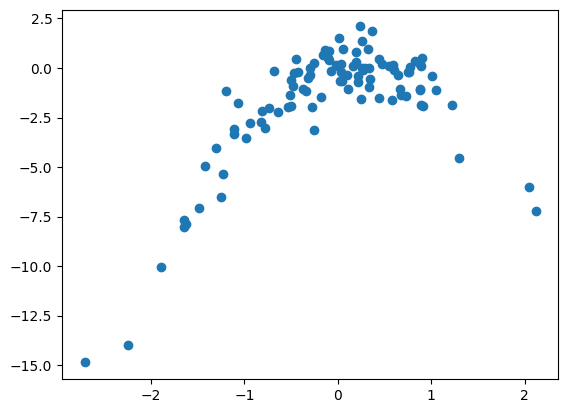

In [99]:
import matplotlib.pyplot as plt
plt.scatter(x, y)

**Comment:** The relationship between x and y is non-linear. Most of the x values are between -1 and 1, and most of y values are between -2 and 2. When x<0, as x increases, y increases. When x>0, as x increases, y decreases

* (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:
  * i. $Y=\beta_0+\beta_1 X+\epsilon$
  * ii. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\epsilon$
  * iii. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\beta_3 X^3+\epsilon$
  * iv. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\beta_3 X^3+\beta_4 X^4+\epsilon$.

Note you may find it helpful to use the data.frame() function to create a single data set containing both $X$ and $Y$.


In [101]:
# create a DataFrame with all polynomial x and y
import pandas as pd

df = pd.DataFrame({
    'X1': x,
    'X2': x**2,
    'X3': x**3,
    'X4': x**4,
    'Y': y
})

df.head()

,X1,X2,X3,X4,Y
0,0.345584,0.119428,0.041273,0.014263,-0.544554
1,0.821618,0.675056,0.554639,0.455701,0.333950
2,0.330437,0.109189,0.036080,0.011922,-0.013532
3,-1.303157,1.698219,-2.213046,2.883947,-4.030442
4,0.905356,0.819669,0.742092,0.671858,0.484861


In [102]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression

In [ ]:
# use LOO fit model1
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model1_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1']].iloc[train_folds]
    X_test = df[['X1']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model1_mse.append((y_test.values - y_pred)**2)

loo_error_model1 = np.mean(model1_mse)
print("Model 1 LOO MSE:", loo_error_model1)

Model 1 LOO MSE: 6.633029839181983


In [134]:
# use LOO fit model2
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model2_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2']].iloc[train_folds]
    X_test = df[['X1','X2']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model2_mse.append((y_test.values - y_pred)**2)

loo_error_model2 = np.mean(model2_mse)
print("Model 2 LOO MSE:", loo_error_model2)

Model 2 LOO MSE: 1.1229368563419684


In [136]:
# use LOO fit model3
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model3_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2','X3']].iloc[train_folds]
    X_test = df[['X1','X2','X3']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model3_mse.append((y_test.values - y_pred)**2)

loo_error_model3 = np.mean(model3_mse)
print("Model 3 LOO MSE:", loo_error_model3)

Model 3 LOO MSE: 1.301796548935888


In [138]:
# use LOO fit model4
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model4_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2','X3','X4']].iloc[train_folds]
    X_test = df[['X1','X2','X3','X4']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model4_mse.append((y_test.values - y_pred)**2)

loo_error_model4 = np.mean(model4_mse)
print("Model 4 LOO MSE:", loo_error_model4)

Model 4 LOO MSE: 1.332394269417934


* (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?


In [148]:
# rerun three models with different random seed

np.random.seed(123) # set random seed
loo = LeaveOneOut()

# create a list to store the LOO MSE results
model_mse = [[] for _ in range(4)]

# create a vector to store variables used in the four models
var_list = [['X1'],['X1','X2'],['X1','X2','X3'],['X1','X2','X3','X4']]

# loop through each model
for i, v in enumerate(var_list):

  # split model to tain and test using LOO
  for train_folds, val_folds in loo.split(df):

      X_train = df[v].iloc[train_folds]
      X_test = df[v].iloc[val_folds]
      y_train = df['Y'][train_folds]
      y_test = df['Y'][val_folds]

      # fit linear regression model
      model = LinearRegression()
      model.fit(X_train, y_train)

      # get model results
      y_pred = model.predict(X_test)

      # calculate mse
      model_mse[i].append((y_test.values - y_pred)**2)

  print(f"Model {i+1} LOO MSE:", np.mean(model_mse[i]))

Model 1 LOO MSE: 6.633029839181983
Model 2 LOO MSE: 1.1229368563419684
Model 3 LOO MSE: 1.301796548935888
Model 4 LOO MSE: 1.332394269417934


**Comment:** The result is same as what I got in (c)

* (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.


**Answer:** The second model $Y=\beta_0+\beta_1 X+\beta_2 X^2+\epsilon$ has the smallest LOOCV error. This is expected because the model function aligns with the function used to generate the data x and y


* (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?


In [170]:
import statsmodels.api as sm

# model1
X1 = sm.add_constant(df[['X1']])
model1 = sm.OLS(df['Y'], X1).fit()
print('The significance of the model1 x coefficient is:', model1.pvalues.iloc[1],'\n')

# model 2
X2 = sm.add_constant(df[['X1','X2']])
model2 = sm.OLS(df['Y'], X2).fit()
print('The significance of the model2 x coefficient is:', model2.pvalues.iloc[1])
print('The significance of the model2 x^2 coefficient is:', model2.pvalues.iloc[2],'\n')

# model 3
X3 = sm.add_constant(df[['X1','X2','X3']])
model3 = sm.OLS(df['Y'], X3).fit()
print('The significance of the model3 x coefficient is:', model3.pvalues.iloc[1])
print('The significance of the model3 x^2 coefficient is:', model3.pvalues.iloc[2])
print('The significance of the model3 x^3 coefficient is:', model3.pvalues.iloc[3],'\n')

# model 3
X4 = sm.add_constant(df[['X1','X2','X3','X4']])
model4 = sm.OLS(df['Y'], X4).fit()
print('The significance of the model4 x coefficient is:', model4.pvalues.iloc[1])
print('The significance of the model4 x^2 coefficient is:', model4.pvalues.iloc[2])
print('The significance of the model4 x^3 coefficient is:', model4.pvalues.iloc[3])
print('The significance of the model4 x^4 coefficient is:', model4.pvalues.iloc[4])

The significance of the model1 x coefficient is: 1.0365062391097462e-09 

The significance of the model2 x coefficient is: 1.4949127104685944e-11
The significance of the model2 x^2 coefficient is: 1.3400677700015243e-39 

The significance of the model3 x coefficient is: 4.4485155714979535e-08
The significance of the model3 x^2 coefficient is: 3.968905542529493e-37
The significance of the model3 x^3 coefficient is: 0.28720183125006776 

The significance of the model4 x coefficient is: 2.5912962860712868e-05
The significance of the model4 x^2 coefficient is: 2.3960259344287474e-19
The significance of the model4 x^3 coefficient is: 0.6424909798530241
The significance of the model4 x^4 coefficient is: 0.02310661043617233


**Comment:** The OLS results above show that the coefficients of x and x^2 are significant, yet the coefficidents of x^3 and x^4 are not significant (although x^4 coefficient is small enough to be lower than 0.05, but it can not compare with the significance levels of x and x^2). This result lines up with the cross validation.

### Chapter-6

**6.1** It is well-known that ridge regression tends to give similar coefficient values to correlated variables, whereas the lasso may give quite different coefficient values to correlated variables. We will now explore this property in a very simple setting.

Suppose that $n=2, p=2, x_{11}=x_{12}, x_{21}=x_{22}$. Furthermore, suppose that $y_1+y_2=0$ and $x_{11}+x_{21}=0$ and $x_{12}+x_{22}=0$, so that the estimate for the intercept in a least squares, ridge regression, or lasso model is zero: $\hat{\beta}_0=0$.
* (a) Write out the ridge regression optimization problem in this setting.


Answer:
Function: 
$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}
$$

The Ridge optmization function:
$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}))^2
+ \lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_{i1} - \beta_2 x_{i2})^2
+ \lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}\left[(y_1 - \beta_0 - \beta_1 x_{11} - \beta_2 x_{12})^2+(y_2 - \beta_0 - \beta_2 x_{21} - \beta_2 x_{22})^2\right]
+ \lambda(\beta_1^2 + \beta_2^2)
$$

Given:

- n = 2
- \(x_{11} = x_{12}\)
- \(x_{21} = x_{22}\)
- \(y_1 + y_2 = 0\)
- \(x_{11} + x_{21} = 0\)
- \(x_{12} + x_{22} = 0\)
- $\hat{\beta}_0 = 0$

The above Ridge transformed regression optimization function becomes:

$$
\min_{\beta_1,\beta_2}
\left[
(y_1 - \beta_1 x_{11} - \beta_2 x_{11})^2
+
(y_2 - \beta_1 x_{21} - \beta_2 x_{21})^2
\right]
+
\lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_1,\beta_2}
\left[
(y_1 - (\beta_1+\beta_2)x_{11})^2
+
(y_2 - (\beta_1+\beta_2)x_{21})^2
\right]
+
\lambda(\beta_1^2+\beta_2^2).
$$

* (b) Argue that in this setting, the ridge coefficient estimates satisfy $\hat{\beta}_1=\hat{\beta}_2$.


Answer:

From part (a), the term depends only on the sum

$$
\beta_1+\beta_2.
$$

$$
\lambda(\beta_1^2+\beta_2^2).
$$

For any two numbers that add up to the same total. The sum of their squares is smallest when the numbers are equal. So
$$
\lambda(\beta_1^2+\beta_2^2).
$$ 
is minimized when

$$
\beta_1=\beta_2
$$

Therefore, the ridge estimates must satisfy

$$
\hat{\beta}_1=\hat{\beta}_2.
$$